In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.windows import Window
import numpy as np, rasterio, geopandas as gpd, matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

In [9]:
# Load normalized GDP
with rasterio.open(r'READY_data\inputs_normalized\2019_gdp_aligned_025_normalized.tif') as src:
    gdp_norm = src.read(1)

# Load normalized Population
with rasterio.open(r'READY_data\inputs_normalized\2020_pop_aligned_025_normalized.tif') as src:
    pop_norm = src.read(1)

# Load Land Cover (one-hot encoded)
with rasterio.open(r'READY_data\landuse_onehot_025\clipped_history_2020_025_onehot.tif') as src:
    lc_onehot = src.read()  # Shape: (7, H, W)
    print(f"Land Cover shape: {lc_onehot.shape} (7 channels)")

# Load CISI target
with rasterio.open(r'READY_data\labels\2024_CISI_025deg.tif') as src:
    cisi = src.read(1)

print(f"GDP shape: {gdp_norm.shape}")
print(f"Pop shape: {pop_norm.shape}")
print(f"CISI shape: {cisi.shape}")

Land Cover shape: (7, 194, 228) (7 channels)
GDP shape: (194, 228)
Pop shape: (194, 228)
CISI shape: (194, 228)


In [10]:
print("=" * 70)
print("DATA STATISTICS SUMMARY")
print("=" * 70)

# GDP
print("\nGDP (Normalized):")
print(f"  Valid pixels: {(~np.isnan(gdp_norm)).sum():,}")
print(f"  Range: [{np.nanmin(gdp_norm):.4f}, {np.nanmax(gdp_norm):.4f}]")
print(f"  Mean: {np.nanmean(gdp_norm):.4f}")
print(f"  Std: {np.nanstd(gdp_norm):.4f}")

# Population
print("\nPopulation (Normalized):")
print(f"  Valid pixels: {(~np.isnan(pop_norm)).sum():,}")
print(f"  Range: [{np.nanmin(pop_norm):.4f}, {np.nanmax(pop_norm):.4f}]")
print(f"  Mean: {np.nanmean(pop_norm):.4f}")
print(f"  Std: {np.nanstd(pop_norm):.4f}")

# Land Cover
print("\nLand Cover (One-Hot Encoded):")
for i in range(lc_onehot.shape[0]):
    channel = lc_onehot[i]
    ones_count = (channel == 1).sum()
    print(f"  Channel {i}: {ones_count:,} pixels = 1 ({ones_count/channel.size*100:.2f}%)")

# CISI
print("\nCISI (Target):")
print(f"  Valid pixels: {(~np.isnan(cisi)).sum():,}")
print(f"  Range: [{np.nanmin(cisi):.4f}, {np.nanmax(cisi):.4f}]")
print(f"  Mean: {np.nanmean(cisi):.4f}")
print(f"  Std: {np.nanstd(cisi):.4f}")

# Overlap
valid_gdp = ~np.isnan(gdp_norm)
valid_pop = ~np.isnan(pop_norm)
valid_cisi = ~np.isnan(cisi)
all_valid = valid_gdp & valid_pop & valid_cisi

print(f"\n✅ Pixels valid in ALL datasets: {all_valid.sum():,} ({all_valid.sum()/gdp_norm.size*100:.2f}%)")

DATA STATISTICS SUMMARY

GDP (Normalized):
  Valid pixels: 14,277
  Range: [-1.0483, 4.1557]
  Mean: -0.0000
  Std: 1.0000

Population (Normalized):
  Valid pixels: 17,960
  Range: [-2.2972, 2.2874]
  Mean: -0.0000
  Std: 1.0000

Land Cover (One-Hot Encoded):
  Channel 0: 28,058 pixels = 1 (63.43%)
  Channel 1: 4,924 pixels = 1 (11.13%)
  Channel 2: 6,457 pixels = 1 (14.60%)
  Channel 3: 1,244 pixels = 1 (2.81%)
  Channel 4: 66 pixels = 1 (0.15%)
  Channel 5: 2,465 pixels = 1 (5.57%)
  Channel 6: 1,018 pixels = 1 (2.30%)

CISI (Target):
  Valid pixels: 14,922
  Range: [0.0000, 0.7353]
  Mean: 0.0329
  Std: 0.0408

✅ Pixels valid in ALL datasets: 12,496 (28.25%)


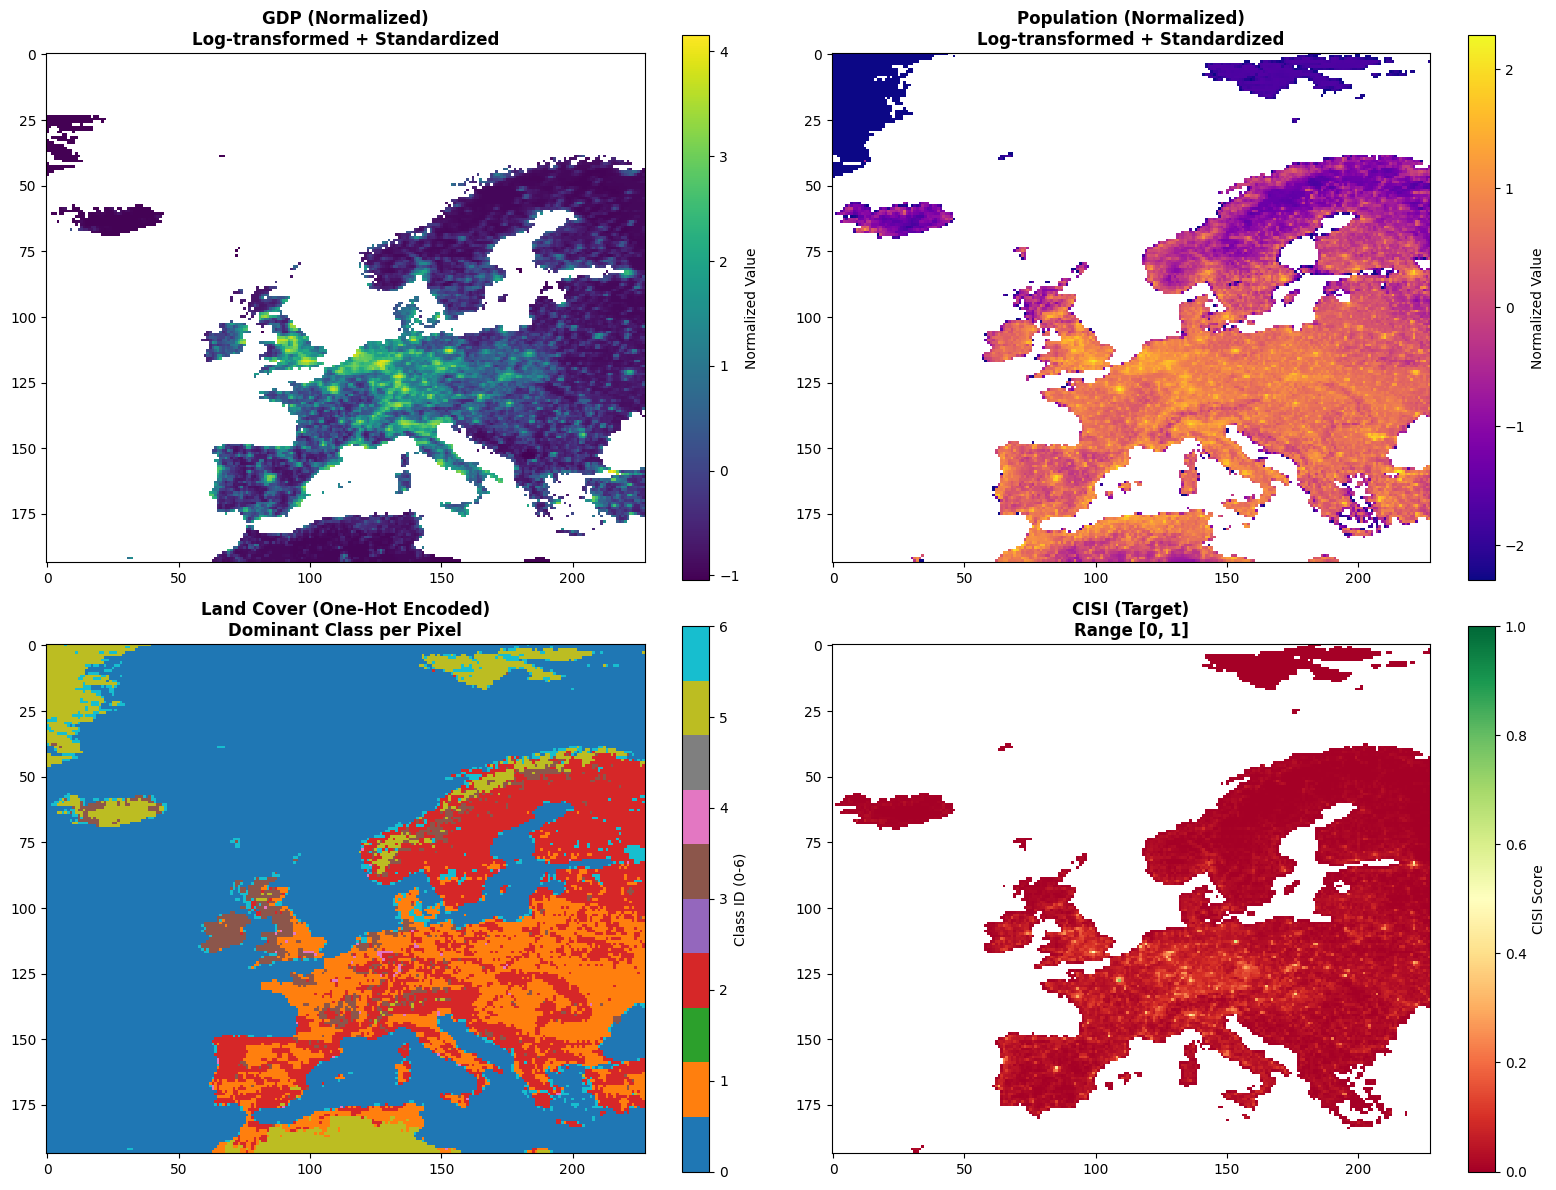

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# GDP
im1 = axes[0, 0].imshow(gdp_norm, cmap='viridis', interpolation='nearest')
axes[0, 0].set_title('GDP (Normalized)\nLog-transformed + Standardized', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 0], label='Normalized Value')

# Population
im2 = axes[0, 1].imshow(pop_norm, cmap='plasma', interpolation='nearest')
axes[0, 1].set_title('Population (Normalized)\nLog-transformed + Standardized', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1], label='Normalized Value')

# Land Cover (create composite by taking argmax across channels)
lc_composite = np.argmax(lc_onehot, axis=0)
lc_composite = lc_composite.astype(float)
# Set to NaN where no class is 1
no_class = (lc_onehot.sum(axis=0) == 0)
lc_composite[no_class] = np.nan

im3 = axes[1, 0].imshow(lc_composite, cmap='tab10', interpolation='nearest')
axes[1, 0].set_title('Land Cover (One-Hot Encoded)\nDominant Class per Pixel', fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=axes[1, 0], label='Class ID (0-6)', ticks=range(7))

# CISI
im4 = axes[1, 1].imshow(cisi, cmap='RdYlGn', interpolation='nearest', vmin=0, vmax=1)
axes[1, 1].set_title('CISI (Target)\nRange [0, 1]', fontsize=12, fontweight='bold')
plt.colorbar(im4, ax=axes[1, 1], label='CISI Score')

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


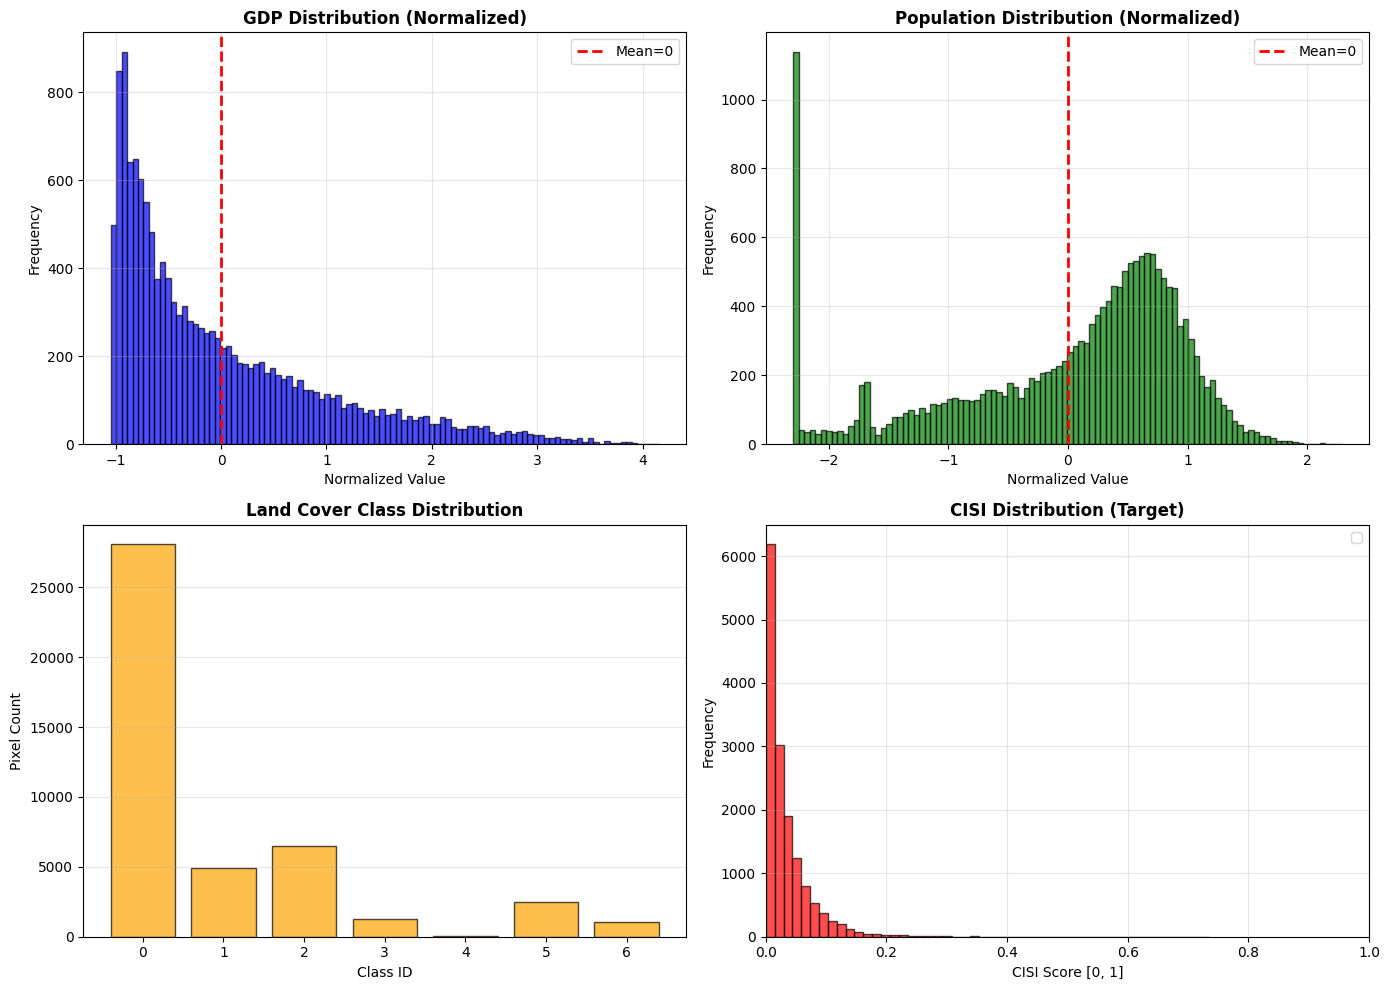

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# GDP histogram
gdp_valid = gdp_norm[~np.isnan(gdp_norm)]
axes[0, 0].hist(gdp_valid, bins=100, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].set_title('GDP Distribution (Normalized)', fontweight='bold')
axes[0, 0].set_xlabel('Normalized Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean=0')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Population histogram
pop_valid = pop_norm[~np.isnan(pop_norm)]
axes[0, 1].hist(pop_valid, bins=100, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Population Distribution (Normalized)', fontweight='bold')
axes[0, 1].set_xlabel('Normalized Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean=0')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Land Cover channel distribution
lc_counts = [lc_onehot[i].sum() for i in range(7)]
axes[1, 0].bar(range(7), lc_counts, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Land Cover Class Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Class ID')
axes[1, 0].set_ylabel('Pixel Count')
axes[1, 0].set_xticks(range(7))
axes[1, 0].grid(True, alpha=0.3, axis='y')

# CISI histogram
cisi_valid = cisi[~np.isnan(cisi)]
axes[1, 1].hist(cisi_valid, bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_title('CISI Distribution (Target)', fontweight='bold')
axes[1, 1].set_xlabel('CISI Score [0, 1]')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

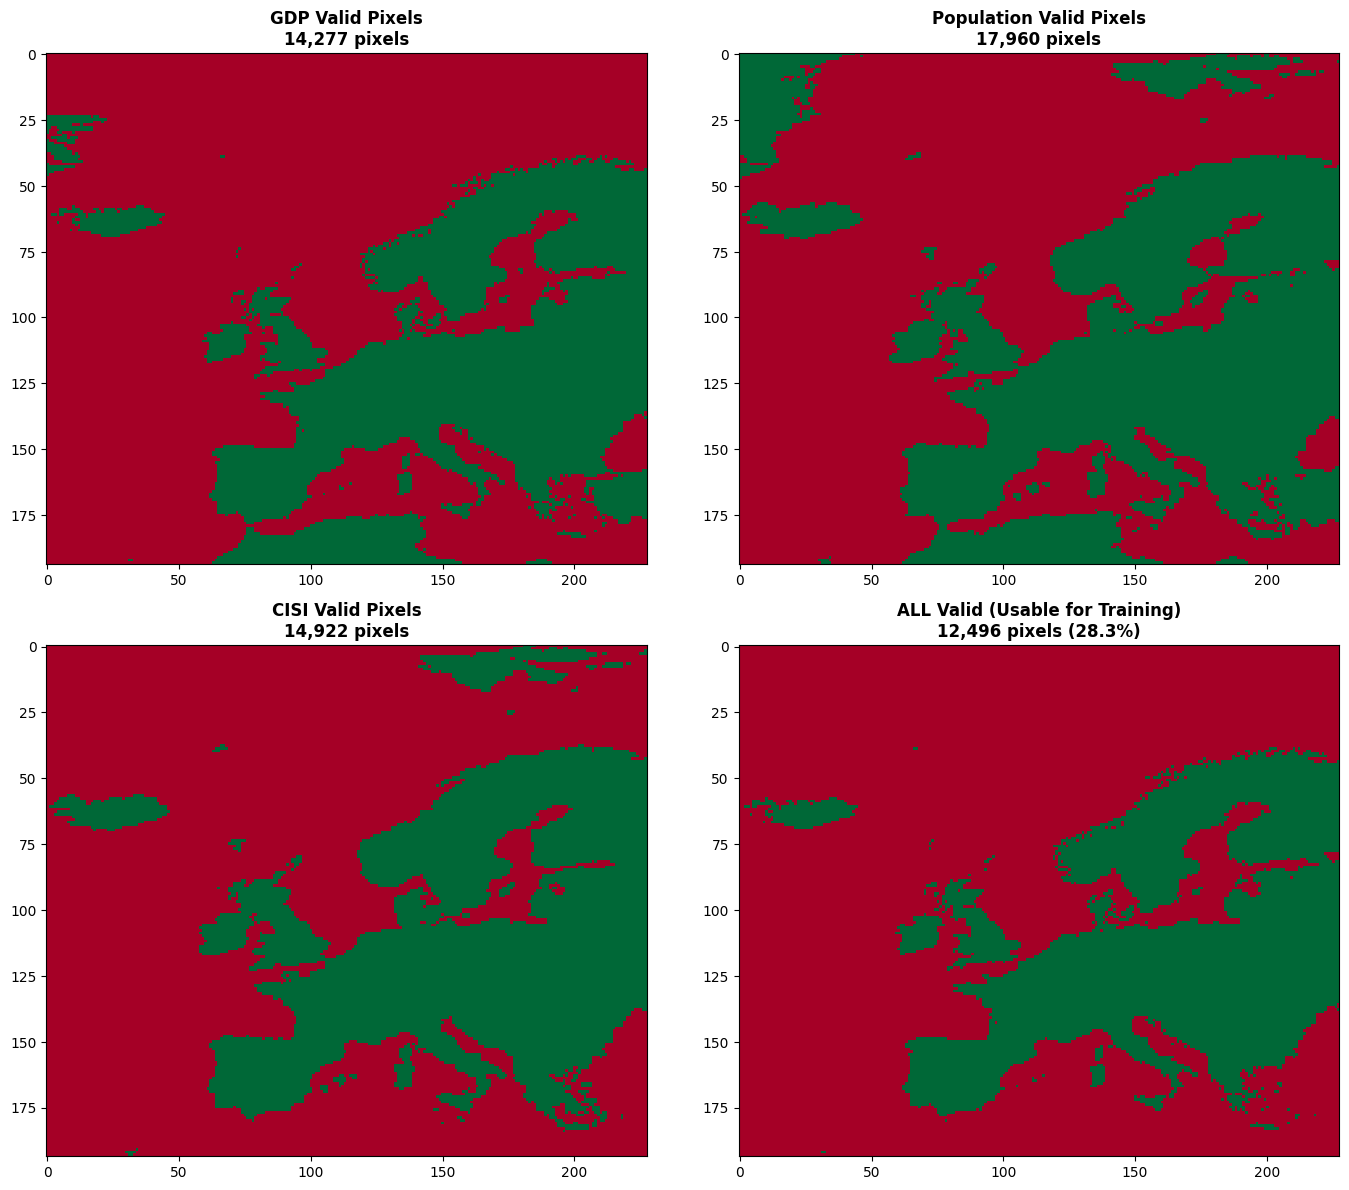

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# GDP valid
axes[0, 0].imshow(~np.isnan(gdp_norm), cmap='RdYlGn', interpolation='nearest')
axes[0, 0].set_title(f'GDP Valid Pixels\n{(~np.isnan(gdp_norm)).sum():,} pixels', fontweight='bold')

# Pop valid
axes[0, 1].imshow(~np.isnan(pop_norm), cmap='RdYlGn', interpolation='nearest')
axes[0, 1].set_title(f'Population Valid Pixels\n{(~np.isnan(pop_norm)).sum():,} pixels', fontweight='bold')

# CISI valid
axes[1, 0].imshow(~np.isnan(cisi), cmap='RdYlGn', interpolation='nearest')
axes[1, 0].set_title(f'CISI Valid Pixels\n{(~np.isnan(cisi)).sum():,} pixels', fontweight='bold')

# All valid (overlap)
axes[1, 1].imshow(all_valid, cmap='RdYlGn', interpolation='nearest')
axes[1, 1].set_title(f'ALL Valid (Usable for Training)\n{all_valid.sum():,} pixels ({all_valid.sum()/gdp_norm.size*100:.1f}%)', 
                    fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
def array_report(arr, name):
    arr = np.asarray(arr)
    print("\n" + "-"*70)
    print(f"{name}")
    print("-"*70)
    print(f"  dtype: {arr.dtype}")
    print(f"  shape: {arr.shape}")

    nan_count = int(np.isnan(arr).sum()) if np.issubdtype(arr.dtype, np.floating) else 0
    inf_count = int(np.isinf(arr).sum()) if np.issubdtype(arr.dtype, np.floating) else 0
    total = arr.size

    print(f"  total: {total}")
    print(f"  NaNs:  {nan_count} ({nan_count/total:.6%})")
    print(f"  Infs:  {inf_count} ({inf_count/total:.6%})")

    if np.issubdtype(arr.dtype, np.number):
        finite = np.isfinite(arr) if np.issubdtype(arr.dtype, np.floating) else np.ones(arr.shape, dtype=bool)
        if finite.any():
            v = arr[finite].astype(np.float64)
            print("  stats (finite only):")
            print(f"    min : {float(v.min()):.6f}")
            print(f"    max : {float(v.max()):.6f}")
            print(f"    mean: {float(v.mean()):.6f}")
            print(f"    std : {float(v.std()):.6f}")
        else:
            print("  stats: no finite values")
    else:
        print("  stats: non-numeric dtype")

def file_nodata_report(path, name):
    with rasterio.open(path) as src:
        print("\n" + "-"*70)
        print(f"{name} FILE INFO")
        print("-"*70)
        print(f"  path: {path}")
        print(f"  nodata: {src.nodata}")
        print(f"  dtype: {src.dtypes}")
        print(f"  count (bands): {src.count}")
        print(f"  size (H,W): ({src.height},{src.width})")
        return src.nodata

def random_patch_nan_locations(gdp, pop, lc, patch=32, n=10, seed=0):
    """
    gdp: (H,W), pop: (H,W), lc: (7,H,W)
    """
    H, W = gdp.shape
    rng = np.random.default_rng(seed)

    print("\n" + "="*70)
    print(f"RANDOM PATCH NaN CHECKS ({n} patches of {patch}x{patch})")
    print("="*70)

    if H < patch or W < patch:
        print("Raster smaller than patch size; skipping.")
        return

    bad = 0
    for i in range(n):
        r0 = int(rng.integers(0, H - patch + 1))
        c0 = int(rng.integers(0, W - patch + 1))

        g_patch = gdp[r0:r0+patch, c0:c0+patch]
        p_patch = pop[r0:r0+patch, c0:c0+patch]

        g_nan = bool(np.isnan(g_patch).any())
        p_nan = bool(np.isnan(p_patch).any())

        if g_nan or p_nan:
            bad += 1
            # show where NaNs are inside the patch (first few coords)
            coords = np.argwhere(np.isnan(g_patch) | np.isnan(p_patch))
            coords_preview = coords[:5].tolist()
            print(f"  Patch {i:02d} @ (row={r0}, col={c0}) -> GDP_NaN={g_nan}, POP_NaN={p_nan}, "
                  f"NaN_coords(sample)={coords_preview}, total_nan_pixels={len(coords)}")
        else:
            print(f"  Patch {i:02d} @ (row={r0}, col={c0}) -> OK (no NaNs in GDP/Pop)")

    print(f"\nSUMMARY: {bad}/{n} patches had NaNs in GDP/Pop.")

# ---------------------------------------------------------
# YOUR LOADS (unchanged)
# ---------------------------------------------------------
GDP_PATH = r'READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif'
POP_PATH = r'READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif'
LC_PATH  = r'READY_data\landuse_onehot\chen2015_lc_onehot.tif'
CISI_PATH= r'READY_data\labels\2024_CISI_010deg.tif'

# File-level nodata info
gdp_nodata = file_nodata_report(GDP_PATH, "GDP")
pop_nodata = file_nodata_report(POP_PATH, "POP")
lc_nodata  = file_nodata_report(LC_PATH,  "LANDCOVER")
cisi_nodata= file_nodata_report(CISI_PATH,"CISI")

# Load arrays
with rasterio.open(GDP_PATH) as src:
    gdp_norm = src.read(1).astype(np.float32)

with rasterio.open(POP_PATH) as src:
    pop_norm = src.read(1).astype(np.float32)

with rasterio.open(LC_PATH) as src:
    lc_onehot = src.read().astype(np.float32)  # (7,H,W)
    print(f"\nLand Cover shape: {lc_onehot.shape} (7 channels)")

with rasterio.open(CISI_PATH) as src:
    cisi = src.read(1).astype(np.float32)

print(f"\nGDP shape:  {gdp_norm.shape}")
print(f"Pop shape:  {pop_norm.shape}")
print(f"CISI shape: {cisi.shape}")

# ---------------------------------------------------------
# Array-level checks
# ---------------------------------------------------------
array_report(gdp_norm, "GDP (normalized)")
array_report(pop_norm, "Population (normalized)")
array_report(lc_onehot, "Landcover one-hot (7ch)")
array_report(cisi, "CISI target")

# Shape sanity
print("\n" + "="*70)
print("SHAPE CONSISTENCY")
print("="*70)
H, W = gdp_norm.shape
print(f"  GDP vs POP same shape:  {gdp_norm.shape == pop_norm.shape}")
print(f"  GDP vs CISI same shape: {gdp_norm.shape == cisi.shape}")
print(f"  LC matches (7,H,W):     {lc_onehot.shape == (7, H, W)}")

# If you want: count how many NaNs are in GDP/POP at the SAME pixel locations
both_nan = np.isnan(gdp_norm) & np.isnan(pop_norm)
print("\nNaN overlap:")
print(f"  GDP NaNs: {int(np.isnan(gdp_norm).sum())}")
print(f"  POP NaNs: {int(np.isnan(pop_norm).sum())}")
print(f"  Both NaN at same pixels: {int(both_nan.sum())}")

# Random patch check (this mirrors your dataloader patching issues)
random_patch_nan_locations(gdp_norm, pop_norm, lc_onehot, patch=32, n=20, seed=42)


## Resolution comparison: CISI at 0.25° vs 0.1°

In [ ]:
SHP_PATH = r'ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp'
world = gpd.read_file(SHP_PATH)

# Load rasters
with rasterio.open(r'READY_data\labels\CISI_025deg.tif') as s:
    cisi_025  = s.read(1).astype(np.float32)
    ext_025   = [s.bounds.left, s.bounds.right, s.bounds.bottom, s.bounds.top]
    nd_025    = s.nodata
    prof_025  = s.profile

with rasterio.open(r'READY_data\labels\CISI_010deg.tif') as s:
    cisi_010 = s.read(1).astype(np.float32)
    bounds   = s.bounds
    nd_010   = s.nodata
    prof_010 = s.profile

with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif') as s:
    mask_010      = s.read(1).astype(np.float32)
    mask_010_prof = s.profile

ext_010 = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Coarsen EU mask from 0.1° down to 0.25°
mask_025 = np.zeros((prof_025['height'], prof_025['width']), dtype=np.float32)
reproject(
    source=mask_010,
    destination=mask_025,
    src_transform=mask_010_prof['transform'],
    src_crs=mask_010_prof['crs'],
    dst_transform=prof_025['transform'],
    dst_crs=prof_025['crs'],
    resampling=Resampling.nearest,
)
mask_025 = mask_025.astype(bool)

# Apply masks
if nd_025 is not None:
    cisi_025 = np.where(cisi_025 == nd_025, np.nan, cisi_025)
cisi_025 = np.where(mask_025, cisi_025, np.nan)

cisi_010 = np.where(mask_010.astype(bool), cisi_010, np.nan)
if nd_010 is not None:
    cisi_010 = np.where(cisi_010 == nd_010, np.nan, cisi_010)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, data, ext, title in [
    (axes[0], cisi_025, ext_025, '0.25° resolution'),
    (axes[1], cisi_010, ext_010, '0.1° resolution'),
]:
    im = ax.imshow(data, cmap='YlOrRd', vmin=0, vmax=0.5,
                   origin='upper', extent=ext, aspect='auto')
    world.boundary.plot(ax=ax, linewidth=0.4, color='black')
    ax.set_xlim(2, 9)
    ax.set_ylim(49, 53.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.colorbar(im, ax=ax, label='CISI', fraction=0.03)

# fig.suptitle('Spatial resolution comparison — historic CISI (Benelux & Ruhr)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/cisi_resolution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved \u2192 figures/cisi_resolution_comparison.png")
